### Spatial Distribution of Chronic Wasting Disease (CWD) in Wild and Captive Cervid Populations  
#### Author: Maria Julia Judson
#### This notebook analyzes the distribution of Chronic Wasting Disease (CWD) presence across U.S. states using county-level data from the USGS. It compares wild and captive cervid populations and prepares a cleaned dataset for visualization in Power BI.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
wild_df = pd.read_csv("20250408_CWD_Wild.csv")
captive_df = pd.read_csv("20250408_CWD_Captive.csv")

In [16]:
wild_df.head()

,State,County
0,Alabama,Colbert
1,Alabama,Lauderdale
2,Arkansas,Baxter
3,Arkansas,Benton
4,Arkansas,Boone


In [19]:
captive_df.head()

,State,County,Count
0,Colorado,Delta,2
1,Colorado,Eagle,2
2,Colorado,El Paso,1
3,Colorado,Fremont,1
4,Colorado,Garfield,1


In [20]:
wild_df.columns

Index(['State', 'County'], dtype='object')

In [21]:
captive_df.columns

Index(['State', 'County', 'Count'], dtype='object')

In [22]:
wild_df.columns = wild_df.columns.str.lower().str.strip()
captive_df.columns = captive_df.columns.str.lower().str.strip()

*The dataset represents counties reporting CWD presence. It does not represent the number of individual infected animals.*

In [23]:
wild_summary = wild_df["state"].value_counts().reset_index()
wild_summary.columns = ["state", "wild_affected_counties"]

wild_summary.head()

,state,wild_affected_counties
0,Nebraska,68
1,Kansas,64
2,Wisconsin,49
3,Missouri,41
4,Montana,37


Number of counties with detections of CWD in wild cervids.

In [24]:
captive_summary = captive_df["state"].value_counts().reset_index()
captive_summary.columns = ["state", "captive_affected_counties"]

captive_summary.head()

,state,captive_affected_counties
0,Wisconsin,32
1,Texas,23
2,Colorado,17
3,Pennsylvania,17
4,Minnesota,12


Number of counties with detections of CWD in captive cervids.

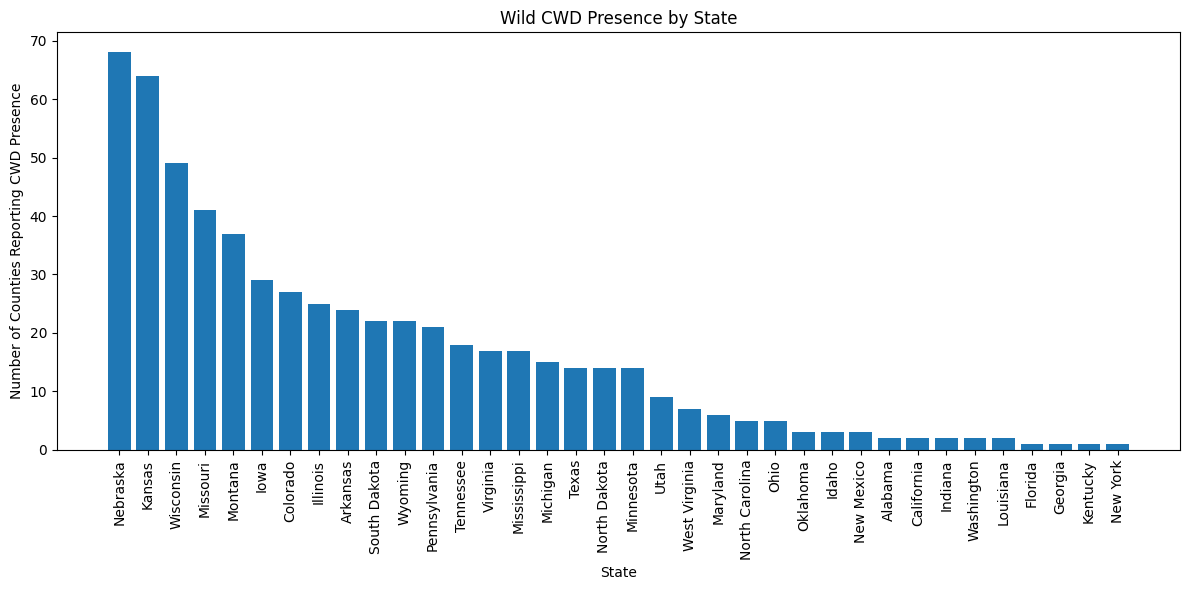

In [25]:
wild_summary_sorted = wild_summary.sort_values(
    by="wild_affected_counties",
    ascending=False
)

plt.figure(figsize=(12, 6))
plt.bar(
    wild_summary_sorted["state"],
    wild_summary_sorted["wild_affected_counties"]
)

plt.title("Wild CWD Presence by State")
plt.xlabel("State")
plt.ylabel("Number of Counties Reporting CWD Presence")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

This graph highlights Midwestern regions showing the highest number of counties reporting the disease in wild cervids. This indicates a strong geographic clustering rather than an even distribution across the United States.

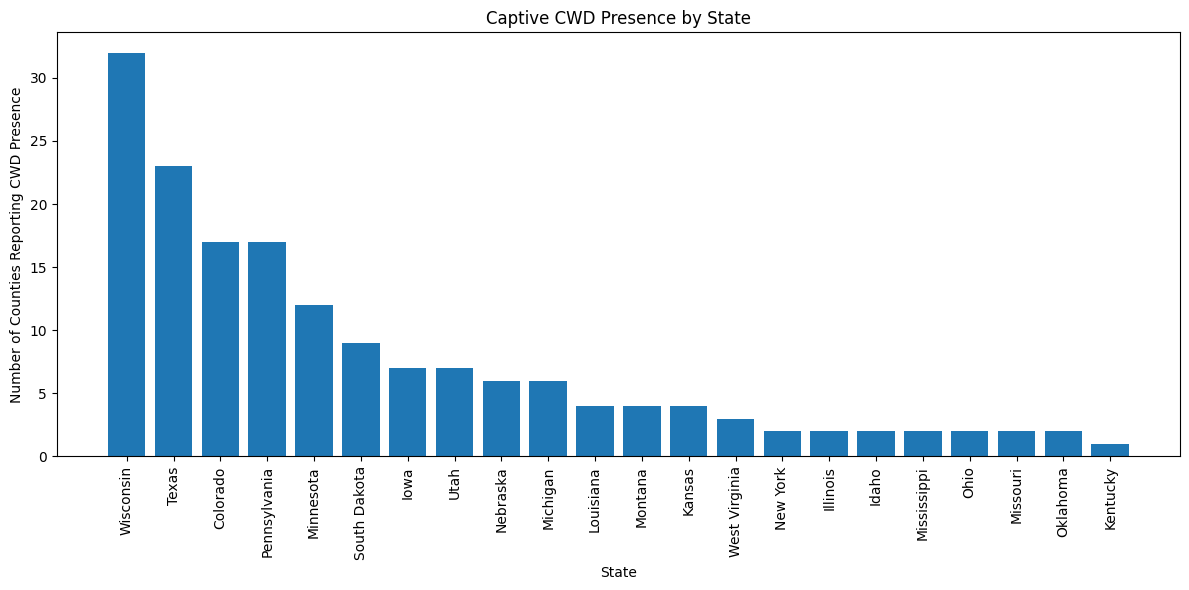

In [26]:
# Sort captive data
captive_summary_sorted = captive_summary.sort_values(
    by="captive_affected_counties",
    ascending=False
)

plt.figure(figsize=(12, 6))

plt.bar(
    captive_summary_sorted["state"],
    captive_summary_sorted["captive_affected_counties"]
)

plt.title("Captive CWD Presence by State")
plt.xlabel("State")
plt.ylabel("Number of Counties Reporting CWD Presence")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

Captive CWD presence is reported in fewer states and across fewer counties compared to wild populations, suggesting a more limited and localized distribution.

In [27]:
combined = pd.merge(
    wild_summary,
    captive_summary,
    on="state",
    how="outer"
).fillna(0)

combined.head()

,state,wild_affected_counties,captive_affected_counties
0,Alabama,2,0.0
1,Arkansas,24,0.0
2,California,2,0.0
3,Colorado,27,17.0
4,Florida,1,0.0


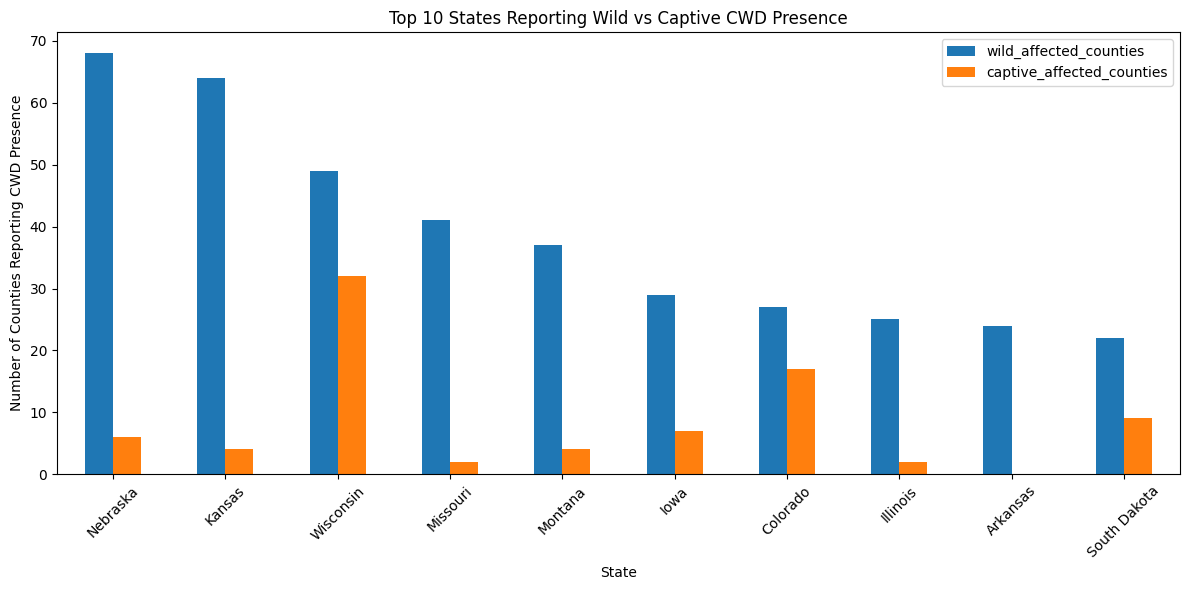

In [32]:
combined_sorted = combined.sort_values(
    by="wild_affected_counties",
    ascending=False
).head(10)

combined_sorted.set_index("state")[[
    "wild_affected_counties",
    "captive_affected_counties"
]].plot(kind="bar", figsize=(12,6))

plt.title("Top 10 States Reporting Wild vs Captive CWD Presence")
plt.xlabel("State")
plt.ylabel("Number of Counties Reporting CWD Presence")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Wild cervid populations show CWD presence across a significantly larger number of counties compared to captive populations, indicating a broader geographic spread in free-ranging populations. Captive CWD presence appears more limited and localized, suggesting different transmission dynamics compared to wild populations.

